<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#📊-Основные-KPI,-эффективность-процессов:" data-toc-modified-id="📊-Основные-KPI,-эффективность-процессов:-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>📊 Основные KPI, эффективность процессов:</a></span><ul class="toc-item"><li><span><a href="#Общее-время-решения-тикета" data-toc-modified-id="Общее-время-решения-тикета-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Общее время решения тикета</a></span></li><li><span><a href="#Среднее-и-медианное-время-решения-тикета-в-разрезе-по-приоритетам" data-toc-modified-id="Среднее-и-медианное-время-решения-тикета-в-разрезе-по-приоритетам-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Среднее и медианное время решения тикета в разрезе по приоритетам</a></span></li><li><span><a href="#Процент-соблюдения-SLA,-процент-просрочек" data-toc-modified-id="Процент-соблюдения-SLA,-процент-просрочек-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Процент соблюдения SLA, процент просрочек</a></span></li></ul></li><li><span><a href="#📅-Метрики-загрузки" data-toc-modified-id="📅-Метрики-загрузки-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>📅 Метрики загрузки</a></span><ul class="toc-item"><li><span><a href="#Общее-количество-тикетов" data-toc-modified-id="Общее-количество-тикетов-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Общее количество тикетов</a></span></li><li><span><a href="#Распределение-тикетов-по-приоритетам" data-toc-modified-id="Распределение-тикетов-по-приоритетам-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Распределение тикетов по приоритетам</a></span></li><li><span><a href="#Распределение-тикетов-по-меткам" data-toc-modified-id="Распределение-тикетов-по-меткам-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Распределение тикетов по меткам</a></span></li><li><span><a href="#Еженедельный/ежемесячный-объем-тикетов,-сезонность-по-дням-недели,-времени-суток-создания-тикетов" data-toc-modified-id="Еженедельный/ежемесячный-объем-тикетов,-сезонность-по-дням-недели,-времени-суток-создания-тикетов-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Еженедельный/ежемесячный объем тикетов, сезонность по дням недели, времени суток создания тикетов</a></span></li></ul></li><li><span><a href="#🔄-Метрика-повторных-обращений" data-toc-modified-id="🔄-Метрика-повторных-обращений-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>🔄 Метрика повторных обращений</a></span><ul class="toc-item"><li><span><a href="#Процент-тикетов,-возращавшихся-в-работу-после-их-закрытия" data-toc-modified-id="Процент-тикетов,-возращавшихся-в-работу-после-их-закрытия-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Процент тикетов, возращавшихся в работу после их закрытия</a></span></li></ul></li><li><span><a href="#⏱️-Время-в-статусах" data-toc-modified-id="⏱️-Время-в-статусах-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>⏱️ Время в статусах</a></span><ul class="toc-item"><li><span><a href="#Распределение-времени-по-статусам" data-toc-modified-id="Распределение-времени-по-статусам-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Распределение времени по статусам</a></span></li></ul></li><li><span><a href="#👤📈-KPI-исполнителей" data-toc-modified-id="👤📈-KPI-исполнителей-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>👤📈 KPI исполнителей</a></span><ul class="toc-item"><li><span><a href="#Процент-тикетов,-решенных-тем-же-исполнителем" data-toc-modified-id="Процент-тикетов,-решенных-тем-же-исполнителем-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Процент тикетов, решенных тем же исполнителем</a></span></li><li><span><a href="#Медианное-время-решения-на-исполнителя" data-toc-modified-id="Медианное-время-решения-на-исполнителя-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Медианное время решения на исполнителя</a></span></li><li><span><a href="#Эффективность-по-меткам-исполнителя" data-toc-modified-id="Эффективность-по-меткам-исполнителя-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>Эффективность по меткам исполнителя</a></span></li></ul></li></ul></div>

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from matplotlib.colors import ListedColormap
#import warnings
#warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set(style="whitegrid", palette="gray")

#SLA
#     'P1': 2,    # 2 часа
#     'P2': 24,   # 1 день
#     'P3': 72,   # 3 дня
#     'P4': 168,  # 7 дней
#     'P5': 720   # 30 дней

In [201]:
df = pd.read_csv('df.csv', parse_dates=['created_date', 'resolved_date'])
df_status = pd.read_csv('ticket_status_history_detailed_last_ver.csv', parse_dates=['changed_date'])

In [202]:
df.head()

,Unnamed: 0,ticket_id,ticket_name,created_date,resolved_date,first_status,last_status,first_assignee,last_assignee,priority,tag,sla_hours
0,0,1,SD-911_6000001,2024-10-09 22:29:30,2024-10-10 03:29:30,Ожидает обработки,В работу,aplyukhina,mburuhin,P3,oe_rsp,72
1,1,2,SD-911_6000002,2024-11-02 11:26:01,2024-11-02 23:26:01,Ожидает обработки,В работу,msharova,rkarvenov,P4,oe_posting_problem,168
2,2,3,SD-911_6000003,2025-01-06 05:48:06,2025-01-10 02:48:06,Ожидает обработки,Выполнено,ymosyagina,ymosyagina,P2,NaN,24
3,3,4,SD-911_6000004,2024-11-25 01:19:34,2024-11-25 02:19:34,Ожидает обработки,В работу,nikiforovaana,nikiforovaana,P3,oe_rsp,72
4,4,5,SD-911_6000005,2024-12-05 23:59:56,2024-12-06 09:59:56,Ожидает обработки,В работу,agliskov,msharova,P4,oe_notcorrect,168


In [203]:
df_status.head()

,ticket_id,status,assignee,changed_date
0,1,Ожидает обработки,dnoosan,2024-11-28 20:20:59
1,1,В работе,dnoosan,2024-11-29 00:41:31
2,1,Ожидается ответ пользователя,nikiforovaana,2024-11-29 06:53:07
3,1,В работе,asayfuddinov,2024-11-29 16:18:50
4,1,Выполнено,dnoosan,2024-11-29 19:47:48


In [204]:
df = df.drop(df.columns[0], axis=1)

In [205]:
df['last_status'] = df['last_status'].replace('В работу', 'В работе')

In [206]:
#df.info()

In [207]:
#df.describe()

### 📊 Основные KPI, эффективность процессов:

#### Общее время решения тикета

In [208]:
# Общее время решения тикетов в часах
df['resolution_in_hours'] = (df['resolved_date'] - df['created_date']).dt.total_seconds() / 3600

#### Среднее и медианное время решения тикета в разрезе по приоритетам

In [209]:
#Среднее и медианное время решения тикетов в разрезе по приоритетам
#за месяц
df.query('created_date > "2025-01-01" and created_date < "2025-01-30"')\
    .groupby('priority', as_index=False)['resolution_in_hours']\
    .agg(['mean', 'median'])

,mean,median
priority,,
P1,6.555556,2.0
P2,24.692308,4.0
P3,40.163265,7.0
P4,66.202899,10.0
P5,106.000000,10.0


#### Процент соблюдения SLA, процент просрочек

In [210]:
# Проверка соблюдения SLA
# True, если SLA нарушен
df['sla_violation'] = df['resolution_in_hours'] > df['sla_hours']
# True, если SLA не нарушен
df['sla_compliance'] = ~df['sla_violation']

In [211]:
df['sla_compliance'].value_counts()
#239 тикетов с нарушенным SLA

True     761
False    239
Name: sla_compliance, dtype: int64

Нарушено SLA: 239
Соблюдено SLA: 761


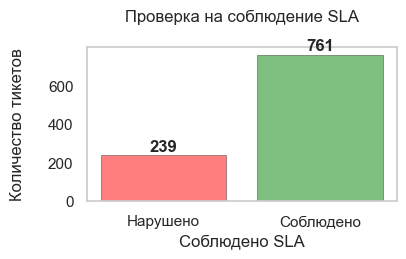

In [212]:
# Проверка соблюдения SLA
df['sla_compliance'] = df['resolution_in_hours'] <= df['sla_hours']

# Считаем количество
violated = (df['sla_compliance'] == False).sum()  # Нарушено
complied = (df['sla_compliance'] == True).sum()   # Соблюдено

print(f"Нарушено SLA: {violated}")
print(f"Соблюдено SLA: {complied}")

# фиксируем данные для графика в правильном порядке: сначала нарушено, потом соблюдено
counts = [violated, complied]  
labels = ['Нарушено', 'Соблюдено']
colors = ['red', 'green']

# график
plt.figure(figsize=(4, 2))
plt.bar(labels, counts, color=colors, alpha=0.5, edgecolor='black', linewidth=0.5)
plt.title('Проверка на соблюдение SLA\n')
plt.xlabel('Соблюдено SLA')
plt.ylabel('Количество тикетов\n')

# цифры на столбцы
for i, count in enumerate(counts):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontweight='bold')

plt.grid(False)
plt.show()

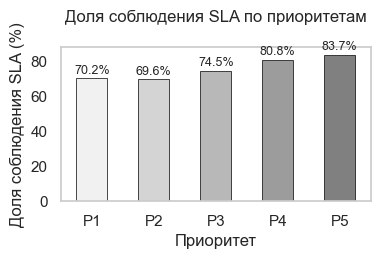

In [213]:
#Сгруппируем по приоритетам, расчет в процентах, дату не ограничиваем, строим по всему df
#Какой процент тикетов в разрезе по приоритетам был обработан в срок
sla_priority = df.groupby('priority')['sla_compliance'].mean() * 100

plt.figure(figsize=(4, 2))
colors = sns.light_palette("gray", n_colors=len(sla_priority))
ax = sla_priority.plot(kind='bar',
                  color=colors,
                  edgecolor='black',  # черная обводка
                  linewidth=0.5) #толщина обводки
plt.title('Доля соблюдения SLA по приоритетам\n')
plt.xlabel('Приоритет')
plt.ylabel('Доля соблюдения SLA (%)')
plt.xticks(rotation=0)
plt.grid(False)

# Добавляем подписи с процентами на столбцы
for i, v in enumerate(sla_priority):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    
plt.show()
#если требуется сохранить картинку
#plt.savefig('SLA_priority.jpg', dpi=300, bbox_inches='tight')


In [214]:
# Общие выводы по соблюденияm SLA
sla_stats = df.groupby('priority')['sla_compliance'].mean() * 100

print(f'В тикетах с меткой P1 SLA соблюден в {sla_stats.get("P1", 0):.1f} процентах случаев')
print("=" * 59)
print(f'В тикетах с меткой P2 SLA соблюден в {sla_stats.get("P2", 0):.1f} процентах случаев')
print("=" * 59)
print(f'В тикетах с меткой P3 SLA соблюден в {sla_stats.get("P3", 0):.1f} процентах случаев')
print("=" * 59)
print(f'В тикетах с меткой P4 SLA соблюден в {sla_stats.get("P4", 0):.1f} процентах случаев')
print("=" * 59)
print(f'В тикетах с меткой P5 SLA соблюден в {sla_stats.get("P5", 0):.1f} процентах случаев')

В тикетах с меткой P1 SLA соблюден в 70.2 процентах случаев
В тикетах с меткой P2 SLA соблюден в 69.6 процентах случаев
В тикетах с меткой P3 SLA соблюден в 74.5 процентах случаев
В тикетах с меткой P4 SLA соблюден в 80.8 процентах случаев
В тикетах с меткой P5 SLA соблюден в 83.7 процентах случаев


### 📅 Метрики загрузки

#### Общее количество тикетов

In [248]:
df.ticket_id.nunique()

1000

In [249]:
df_status.ticket_id.nunique() #в датафрейме со статусами сформировано больше

500

#### Распределение тикетов по приоритетам

In [216]:
ticket_counts = df['priority'].value_counts().sort_index()

print("Количество тикетов по приоритетам:")
print("=" * 35)
for priority, count in ticket_counts.items():
    priority = "Без метки" if pd.isna(priority) else priority
    print(f"{priority}: {count} тикетов")

Количество тикетов по приоритетам:
P1: 57 тикетов
P2: 161 тикетов
P3: 404 тикетов
P4: 292 тикетов
P5: 86 тикетов


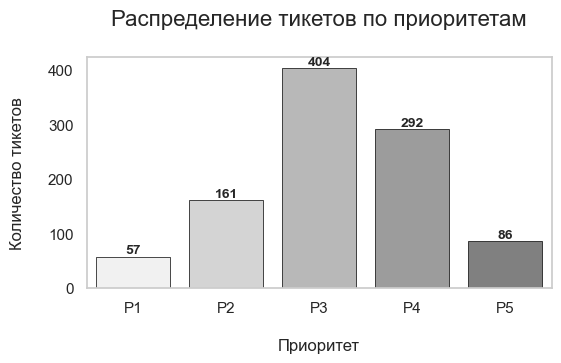

In [217]:
#Визуализируем распределение тикетов по приоритетам
#Порядок приоритетов фиксируем
priority_order = ['P1', 'P2', 'P3', 'P4', 'P5']

#plt.style.use('default')

plt.figure(figsize=(6, 3))



colors = sns.light_palette("gray", n_colors=len(priority_order))

ax = sns.countplot(data=df, x='priority', order=priority_order, 
              palette=colors, 
              edgecolor='black',  # черная обводка
              linewidth=0.5)      # толщина обводки

plt.title('Распределение тикетов по приоритетам\n', fontsize=16)
plt.xlabel('\nПриоритет')
plt.ylabel('Количество тикетов\n')
plt.grid(False)

# Подписываем значения столбцов
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',  # преобразуем в целое число
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
#если требуется сохранить картинку
#plt.savefig('priority_count.jpg', dpi=300, bbox_inches='tight')    
plt.show()

#### Распределение тикетов по меткам

In [218]:
#Количество тикетов по меткам
# Включая тикеты, где не указали метку
tag_counts = df['tag'].value_counts(dropna=False).sort_index()

print("Количество тикетов по меткам (включая пустые):")
print("=" * 45)
for tag, count in tag_counts.items():
    tag_name = "Без метки" if pd.isna(tag) else tag
    print(f"{tag_name}: {count} тикетов")

Количество тикетов по меткам (включая пустые):
oe_cargo: 96 тикетов
oe_consig: 47 тикетов
oe_consig_asgard: 19 тикетов
oe_datafix: 83 тикетов
oe_incident_bo: 17 тикетов
oe_inventory: 94 тикетов
oe_kiz: 37 тикетов
oe_move_fresh_to_fresh: 21 тикетов
oe_move_fresh_to_wms: 16 тикетов
oe_notcorrect: 71 тикетов
oe_pldcs: 19 тикетов
oe_posting_problem: 151 тикетов
oe_posting_pushing: 46 тикетов
oe_returns: 129 тикетов
oe_rsp: 82 тикетов
oe_synk: 57 тикетов
Без метки: 15 тикетов


In [219]:
# Общее количество тикетов с метками
tickets_with_tags = df['tag'].notna().sum()
# Количество тикетов без меток
tickets_without_tags = df['tag'].isna().sum()

print(f"Тикетов с метками: {tickets_with_tags}")
print(f"Тикетов без меток: {tickets_without_tags}")

Тикетов с метками: 985
Тикетов без меток: 15


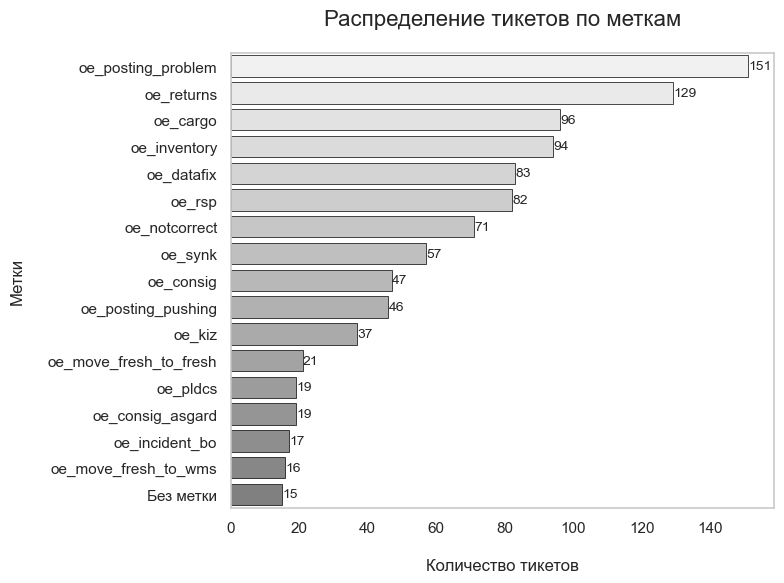

In [220]:
#Визуализируем количество тикетов по меткам

tag_counts = df['tag'].value_counts(dropna=False)
#Заменим пустые значения на "Без метки"
tag_counts.index = ['Без метки' if pd.isna(x) else x for x in tag_counts.index]

#график
plt.figure(figsize=(8, 6))

colors = sns.light_palette("gray", n_colors=len(tag_counts))

ax = sns.barplot(x=tag_counts.values, y=tag_counts.index, 
            palette=colors,
            edgecolor='black',  # черная обводка
            linewidth=0.5)      # толщина обводки

plt.title('Распределение тикетов по меткам', fontsize=16, pad=20)
plt.xlabel('\nКоличество тикетов', fontsize=12)
plt.ylabel('Метки\n', fontsize=12)
plt.grid(False)

# Добавляем значения на столбцы
for i, v in enumerate(tag_counts.values):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=10)

#если требуется сохранить картинку
#plt.savefig('tag_count.jpg', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

#### Еженедельный/ежемесячный объем тикетов, сезонность по дням недели, времени суток создания тикетов

In [221]:
# Извлечение дат
df['created_date_only'] = df['created_date'].dt.date #дата создания тикета, без времени
df['created_week'] = df['created_date'].dt.isocalendar().week #извлекаем неделю года
df['created_month'] = df['created_date'].dt.month #месяц, его порядковый номер
df['created_day_of_week'] = df['created_date'].dt.day_name() #день(имя)
df['created_hour'] = df['created_date'].dt.hour #час

In [222]:
# #закомментировать или раскомментировать, горячие клавиши Ctrl + /
# те же графики по неделям и месяцу, только барплот. оставляем лайнплот для визуализации во времени

# #график
# plt.figure(figsize=(6, 4))

# # Считаем еженедельный объем тикетов, берем только последние 6 недель
# weekly_volume = df.resample('W', on='created_date')['ticket_id'].count().tail(6)
# weekly_labels = weekly_volume.index.strftime('%Y-%m-%d')  # Формат даты

# # Создаем палитру - количество цветов = количеству недель (6)
# colors = sns.light_palette("gray", n_colors=len(weekly_volume))

# # барплот
# ax = sns.barplot(x=weekly_labels, y=weekly_volume.values, 
#                  palette=colors,
#                  edgecolor='black',
#                  linewidth=0.5)

# plt.title('Еженедельный объем созданных тикетов (последние 6 недель)\n', fontsize=16)
# plt.xlabel('\nНеделя')
# plt.ylabel('Количество тикетов\n')
# plt.grid(False)

# # Подписываем значения столбцов
# for p in ax.patches:
#     ax.annotate(f'{int(p.get_height())}',
#                 (p.get_x() + p.get_width() / 2., p.get_height()),
#                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()


# # Второй график

# plt.figure(figsize=(6, 4))

# monthly_volume = df.resample('M', on='created_date')['ticket_id'].count()
# monthly_labels = monthly_volume.index.strftime('%Y-%m') #Оставляем только год-месяц

# colors = sns.light_palette("gray", n_colors=len(monthly_volume)) #количество цветов = количеству месяцев в данных (у нас 4)

# ax = sns.barplot(x=monthly_labels, y=monthly_volume.values, 
#                  palette=colors,
#                  edgecolor='black',
#                  linewidth=0.5)

# plt.title('Ежемесячный объем созданных тикетов\n', fontsize=16)
# plt.xlabel('\nМесяц')
# plt.ylabel('Количество тикетов\n')
# plt.grid(False)

# # Подписываем значения столбцов
# for p in ax.patches:
#     ax.annotate(f'{int(p.get_height())}',
#                 (p.get_x() + p.get_width() / 2., p.get_height()),
#                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# plt.tight_layout()
# plt.show()

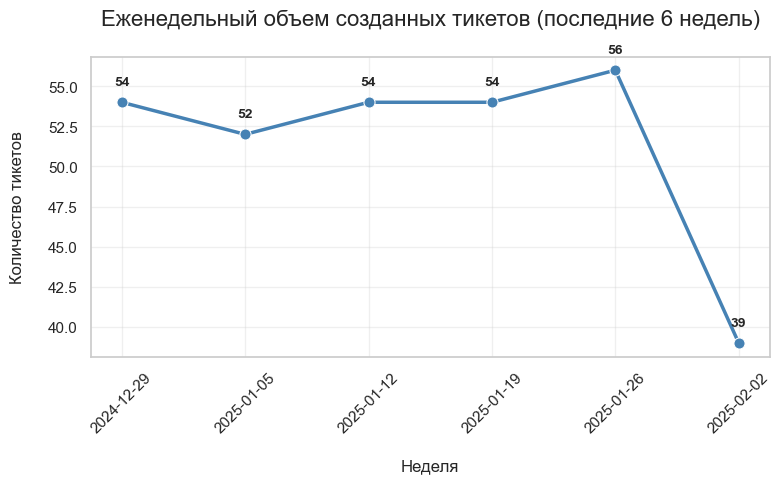

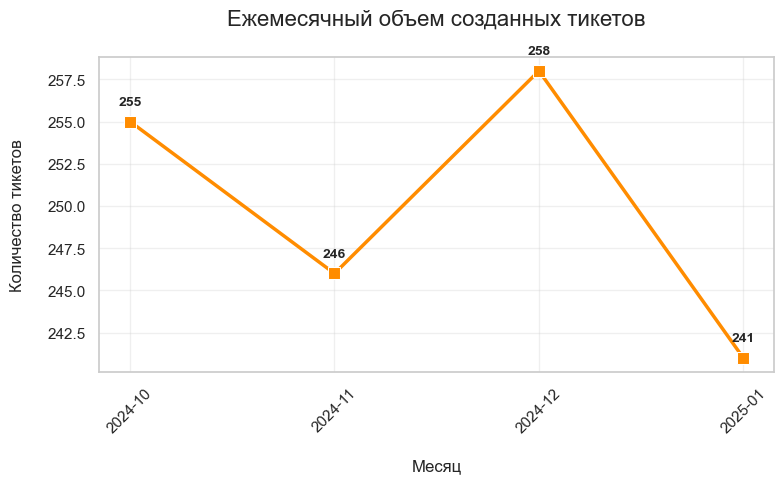

In [223]:
# Считаем еженедельный объем тикетов, берем только последние 6 недель
plt.figure(figsize=(8, 5))
weekly_volume = df.resample('W', on='created_date')['ticket_id'].count().tail(6)
weekly_labels = weekly_volume.index.strftime('%Y-%m-%d')  # Формат даты

# Строим lineplot
ax = sns.lineplot(x=weekly_labels, y=weekly_volume.values, 
                 marker='o', markersize=8, linewidth=2.5,
                 color='steelblue')

plt.title('Еженедельный объем созданных тикетов (последние 6 недель)\n', fontsize=16)
plt.xlabel('\nНеделя')
plt.ylabel('Количество тикетов\n')
plt.grid(True, alpha=0.3)

# Подписываем значения точек
for i, (x, y) in enumerate(zip(weekly_labels, weekly_volume.values)):
    ax.annotate(f'{int(y)}', 
                (x, y),
                xytext=(0, 10), 
                textcoords='offset points',
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Второй график - ежемесячный объем
plt.figure(figsize=(8, 5))

monthly_volume = df.resample('M', on='created_date')['ticket_id'].count()
monthly_labels = monthly_volume.index.strftime('%Y-%m') # Оставляем только год-месяц

# lineplot
ax = sns.lineplot(x=monthly_labels, y=monthly_volume.values, 
                 marker='s', markersize=8, linewidth=2.5,
                 color='darkorange')

plt.title('Ежемесячный объем созданных тикетов\n', fontsize=16)
plt.xlabel('\nМесяц')
plt.ylabel('Количество тикетов\n')
plt.grid(True, alpha=0.3)

# Подписываем значения точек
for i, (x, y) in enumerate(zip(monthly_labels, monthly_volume.values)):
    ax.annotate(f'{int(y)}', 
                (x, y),
                xytext=(0, 10), 
                textcoords='offset points',
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [224]:
# Количество тикетов по месяцам
# df.groupby('created_month').size()

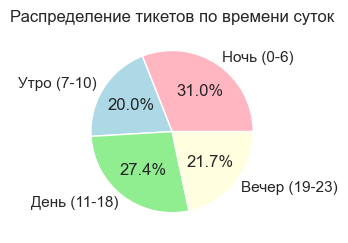

In [225]:
#### Созданные тикеты, объемы по времени суток
hourly_seasonality = df['created_hour'].value_counts().sort_index()

time_intervals = {
    'Ночь (0-6)': df[df['created_hour'].between(0, 6)]['ticket_id'].count(),
    'Утро (7-10)': df[df['created_hour'].between(7, 10)]['ticket_id'].count(),
    'День (11-18)': df[df['created_hour'].between(11, 17)]['ticket_id'].count(),
    'Вечер (19-23)': df[df['created_hour'].between(19, 23)]['ticket_id'].count()
                }
# Пайчарт
plt.subplot(2, 2, 4)
pd.Series(time_intervals).plot(kind='pie', autopct='%1.1f%%', colors=['lightpink', 'lightblue', 'lightgreen', 'lightyellow'])
plt.title('Распределение тикетов по времени суток')
plt.ylabel('')

plt.tight_layout()
# plt.savefig('ticket_seasonality_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 🔄 Метрика повторных обращений

#### Процент тикетов, возращавшихся в работу после их закрытия

In [226]:
# Если тикет был в статусе "Выполнено" или "Отменен", после этого снова перешел в статус "В работе" хотя бы раз

In [227]:
df_status.head()

,ticket_id,status,assignee,changed_date
0,1,Ожидает обработки,dnoosan,2024-11-28 20:20:59
1,1,В работе,dnoosan,2024-11-29 00:41:31
2,1,Ожидается ответ пользователя,nikiforovaana,2024-11-29 06:53:07
3,1,В работе,asayfuddinov,2024-11-29 16:18:50
4,1,Выполнено,dnoosan,2024-11-29 19:47:48


In [228]:
# df_status.query('status == "Выполнено" | status == "Отменен"').value_counts().sum()

In [229]:
# df_status.status.unique()

In [230]:
closed_statuses = ['Выполнено', 'Отменен']
active_statuses = ['В работу', 'В работе', 'В разработке', 'На согласовании', 'Ожидается ответ пользователя']

df_sorted = df_status.sort_values(by=['ticket_id', 'changed_date'])

# Создаем флаги для закрытых и активных статусов
df_sorted['is_closed'] = df_sorted['status'].isin(closed_statuses)
df_sorted['is_active'] = df_sorted['status'].isin(active_statuses)

df_sorted['next_is_active'] = df_sorted.groupby('ticket_id')['is_active'].shift(-1) # Сдвигаем статусы для сравнения со следующими записями
reopened_mask = df_sorted['is_closed'] & df_sorted['next_is_active'] # Находим случаи, когда закрытый статус следует за активным

# Получаем список ticket_id с повторным открытием
reopened_tickets = df_sorted.loc[reopened_mask, 'ticket_id'].unique().tolist()
#reopened_tickets

In [231]:
# Извлечем месяц и год
df_sorted['month'] = df_sorted['changed_date'].dt.to_period('M')

# Найдем все тикеты, которые были закрыты (хотя бы раз)
closed_tickets = df_sorted[df_sorted['status'].isin(closed_statuses)]
closed_tickets_per_month = closed_tickets.groupby('month')['ticket_id'].nunique()

# Тикеты, которые были повторно открыты (используем наш список reopened_tickets)
reopened_df = df_sorted[df_sorted['ticket_id'].isin(reopened_tickets)]
reopened_per_month = reopened_df.groupby('month')['ticket_id'].nunique()

# Расчет процента
percentage_reopened = (reopened_per_month / closed_tickets_per_month * 100).fillna(0)
percentage_reopened

month
2024-10    4.301075
2024-11    6.306306
2024-12    7.608696
2025-01    2.857143
2025-02    4.081633
2025-03    0.000000
Freq: M, Name: ticket_id, dtype: float64

In [232]:
# берем assignee из последнего закрытия для повторно открытых тикетов: выбираем повторно открытые тикеты, 
assignee_reopened = (
    df_sorted[
        (df_sorted['ticket_id'].isin(reopened_tickets)) & 
        (df_sorted['status'].isin(closed_statuses))
    ]
    .groupby('ticket_id')
    .last() #последняя запись для каждой группы (ticket_id)
    .reset_index()[['ticket_id', 'assignee']]
)

assignee_counts = assignee_reopened['assignee'].value_counts()

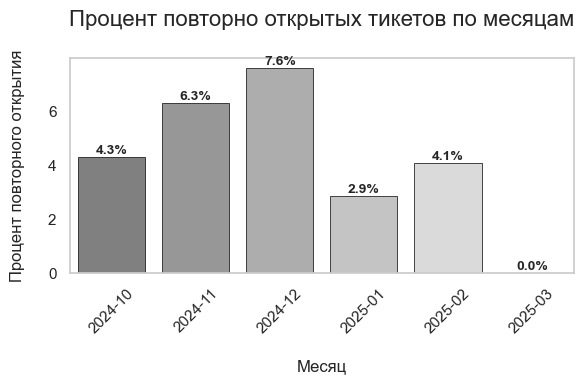

In [233]:
# Сначала создадим result_df из ваших данных
df_sorted['month'] = df_sorted['changed_date'].dt.to_period('M')

# Создаем DataFrame с закрытыми тикетами по месяцам
closed_per_month = (
    df_sorted[df_sorted['status'].isin(closed_statuses)]
    .groupby('month')['ticket_id']
    .nunique()
    .rename('closed_tickets')
)

# Создаем DataFrame с повторно открытыми тикетами по месяцам
reopened_per_month = (
    df_sorted[df_sorted['ticket_id'].isin(reopened_tickets)]
    .groupby('month')['ticket_id']
    .nunique()
    .rename('reopened_tickets')
)

# Объединяем в один DataFrame
result_df = pd.concat([closed_per_month, reopened_per_month], axis=1).fillna(0)

# Расчет процента
result_df['percentage_reopened'] = (result_df['reopened_tickets'] / result_df['closed_tickets'] * 100).fillna(0)

# График
plt.figure(figsize=(6, 4))

monthly_data = result_df.reset_index()
monthly_data['month_str'] = monthly_data['month'].astype(str)

# настройка палитры seaborn
gray_colors = sns.light_palette("gray", n_colors=len(monthly_data), reverse=True)

ax1 = sns.barplot(x='month_str', y='percentage_reopened', data=monthly_data,
                 palette=gray_colors, 
                 edgecolor='black',
                 linewidth=0.5)

plt.title('Процент повторно открытых тикетов по месяцам\n', fontsize=16)
plt.xlabel('\nМесяц')
plt.ylabel('Процент повторного открытия\n')
plt.grid(False)

# Подписываем значения
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

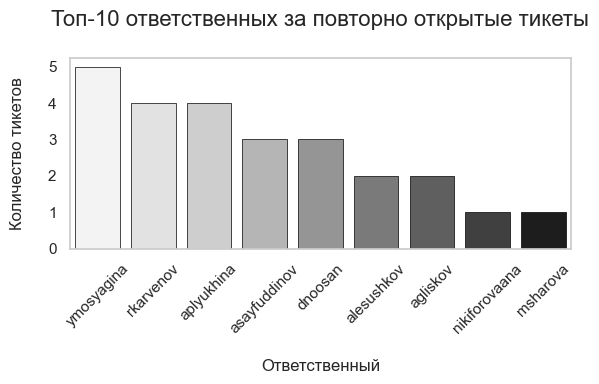

In [234]:
# График распределения ответственных за повторно открытые тикеты
plt.figure(figsize=(6, 4))

if 'assignee_counts' in locals() and len(assignee_counts) > 0:
    top_assignees = assignee_counts.head(10)
    
# серая палитра
    gray_colors = sns.color_palette("Greys", len(top_assignees))
    
    # Строим график
    sns.barplot(x=top_assignees.index, y=top_assignees.values,
                palette=gray_colors, 
                edgecolor='black',
                linewidth=0.5)
    
    plt.title('Топ-10 ответственных за повторно открытые тикеты\n', fontsize=16)
    plt.xlabel('\nОтветственный')
    plt.ylabel('Количество тикетов\n')
    plt.grid(False)
    
    # Подписываем значения
    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Данные по ответственным не найдены")



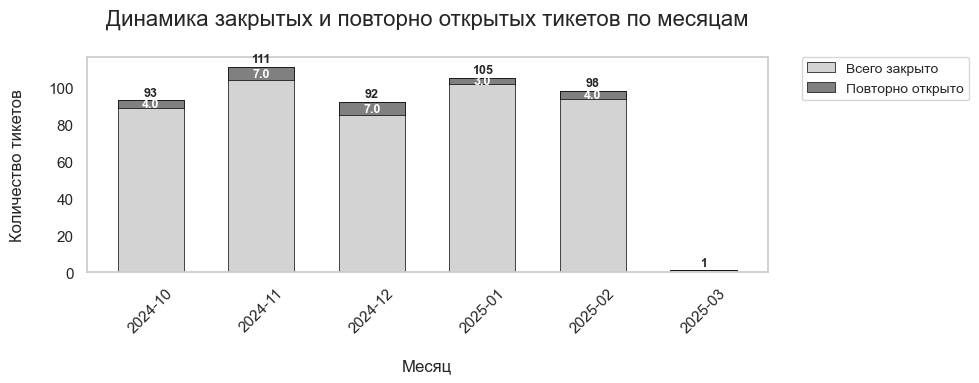

In [235]:
# 3. График абсолютных значений закрытых и повторно открытых тикетов
plt.figure(figsize=(10, 4))

stacked_data = result_df[['closed_tickets', 'reopened_tickets']].reset_index()
stacked_data['month_str'] = stacked_data['month'].astype(str)

ax3 = plt.subplot(111)
width = 0.6

# Серые оттенки для stacked bar chart
light_gray = '#d3d3d3'  # светлосерый
dark_gray = '#808080'   # темносерый

# Столбцы для закрытых тикетов (всего)
bars1 = ax3.bar(stacked_data['month_str'], stacked_data['closed_tickets'], width,
               color=light_gray, 
               edgecolor='black',
               linewidth=0.5, 
               label='Всего закрыто')

# Столбцы для повторно открытых тикетов (поверх)
bars2 = ax3.bar(stacked_data['month_str'], stacked_data['reopened_tickets'], width,
               color=dark_gray, 
               edgecolor='black',
               linewidth=0.5, 
               label='Повторно открыто',
               bottom=stacked_data['closed_tickets'] - stacked_data['reopened_tickets'])

plt.title('Динамика закрытых и повторно открытых тикетов по месяцам\n', fontsize=16)
plt.xlabel('\nМесяц')
plt.ylabel('Количество тикетов\n')
plt.legend()
plt.grid(False)

# Подписываем значения для общего количества закрытых
for i, (bar, value) in enumerate(zip(bars1, stacked_data['closed_tickets'])):
    ax3.text(bar.get_x() + bar.get_width()/2, value + 1, f'{value}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Подписываем значения для повторно открытых
for i, (bar, value) in enumerate(zip(bars2, stacked_data['reopened_tickets'])):
    if value > 0:
        ax3.text(bar.get_x() + bar.get_width()/2, 
                stacked_data['closed_tickets'].iloc[i] - value/2, 
                f'{value}', ha='center', va='center', fontsize=9, 
                fontweight='bold', color='white')

ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title_fontsize=11, fontsize=10) #вынесла легенду справа
        
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

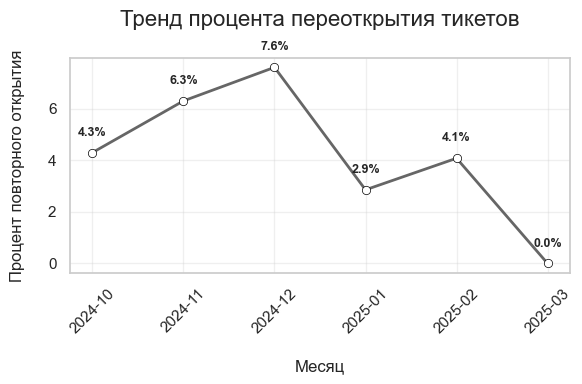

In [236]:
# график тренда повторного открытия
plt.figure(figsize=(6, 4))

# Линейный график тренда
ax4 = plt.subplot(111)
plt.plot(monthly_data['month_str'], monthly_data['percentage_reopened'], 
         marker='o', 
         linewidth=2, 
         markersize=6,
         color='#666666',
         markerfacecolor='white',
         markeredgecolor='black',
         markeredgewidth=0.5)

plt.title('Тренд процента переоткрытия тикетов\n', fontsize=16)
plt.xlabel('\nМесяц')
plt.ylabel('Процент повторного открытия\n')
plt.grid(True, alpha=0.3)

# Подписываем точки
for i, (month, value) in enumerate(zip(monthly_data['month_str'], monthly_data['percentage_reopened'])):
    plt.annotate(f'{value:.1f}%', 
                (month, value),
                xytext=(0, 10),
                textcoords='offset points',
                ha='center', 
                va='bottom',
                fontsize=9,
                fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ⏱️ Время в статусах

#### Распределение времени по статусам

Анализируем распределение времени между активными статусами для уже закрытых тикетов

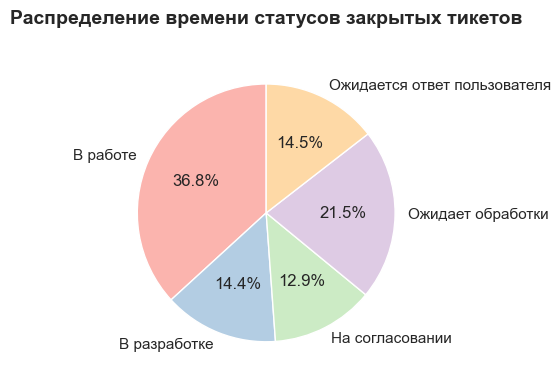

In [237]:
# Определяем статусы
closed_statuses = ['Выполнено', 'Отменен']
active_statuses = ['Ожидает обработки', 'В работе', 'В разработке', 'На согласовании', 'Ожидается ответ пользователя']

# Берем только тикеты в финальных статусах
closed_tickets = df_sorted[df_sorted['status'].isin(closed_statuses)]['ticket_id'].unique()
df_closed = df_sorted[df_sorted['ticket_id'].isin(closed_tickets)].copy()

# Сортируем и рассчитываем время между сменами статусов
df_closed = df_closed.sort_values(['ticket_id', 'changed_date'])
df_closed['next_changed_date'] = df_closed.groupby('ticket_id')['changed_date'].shift(-1)

# Для последней записи каждого тикета используем максимальную дату
max_dates = df_closed.groupby('ticket_id')['changed_date'].max()
for ticket_id in closed_tickets:
    last_idx = df_closed[df_closed['ticket_id'] == ticket_id].index[-1]
    df_closed.loc[last_idx, 'next_changed_date'] = max_dates[ticket_id]

# Фильтруем только активные статусы и рассчитываем время
df_active_times = df_closed[df_closed['status'].isin(active_statuses)].copy()
df_active_times['time_in_status'] = (df_active_times['next_changed_date'] - df_active_times['changed_date']).dt.total_seconds() / 3600

# суммируем время по активным статусам
time_per_active_status = df_active_times.groupby('status')['time_in_status'].sum()
total_active_time = time_per_active_status.sum()
percentage_time_per_status = (time_per_active_status / total_active_time * 100).round(2)

# пайчарт
fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.Pastel1(range(len(active_statuses)))

wedges, texts, autotexts = ax.pie(percentage_time_per_status.values, 
                                  labels=percentage_time_per_status.index,
                                  autopct='%1.1f%%', 
                                  colors=colors,
                                  startangle=90)

ax.set_title('Распределение времени статусов закрытых тикетов', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### 👤📈 KPI исполнителей

#### Процент тикетов, решенных тем же исполнителем

In [238]:
# Фильтруем данные где first_assignee тот же, что и last_assignee
# будем использовать данный фильтр везде, где требуетсярачет статусов
same_assignee_tickets = df[df['first_assignee'] == df['last_assignee']]

ticket_count_per_assignee = same_assignee_tickets['first_assignee'].value_counts()

# Общее количество тикетов по каждому исполнителю (где first_assignee = last_assignee)
total_tickets_per_assignee = df['first_assignee'].value_counts()

# Вычисляем процентное соотношение
percentage_solved_same = (ticket_count_per_assignee / total_tickets_per_assignee) * 100
percentage_solved_same = percentage_solved_same.sort_values(ascending=False)

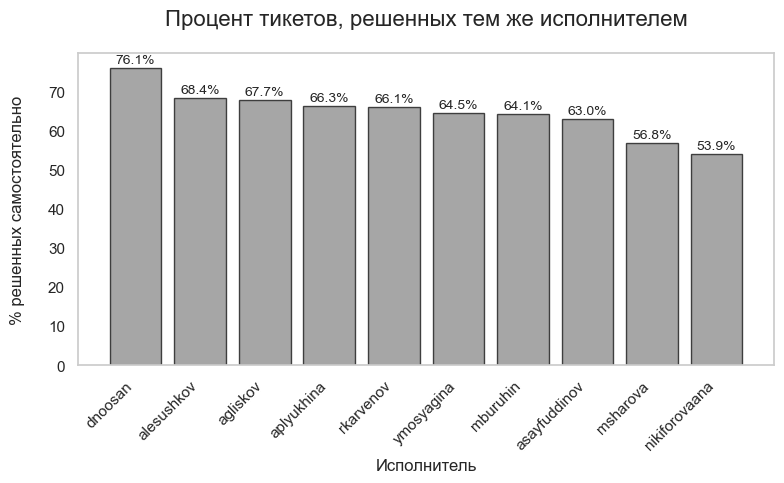

In [239]:
# график
plt.figure(figsize=(8, 5))
bars = plt.bar(percentage_solved_same.index, percentage_solved_same.values, 
               color='gray', edgecolor='black', linewidth=1, alpha=0.7)

# Настройки графика
plt.title('Процент тикетов, решенных тем же исполнителем', fontsize=16, pad=20)
plt.xlabel('Исполнитель', fontsize=12)
plt.ylabel('% решенных самостоятельно\n', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, value in zip(bars, percentage_solved_same.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{value:.1f}%', ha='center', va='bottom', fontsize=10)
plt.grid(False)
plt.tight_layout()
plt.show()

#### Медианное время решения на исполнителя

In [240]:
#same_assignee_tickets = df[df['first_assignee'] == df['last_assignee']]

# вычисляем медианное время решения
median_resolution_time = same_assignee_tickets.groupby('first_assignee')['resolution_in_hours'].agg([
    ('median_time', 'median'), 
    ('ticket_count', 'count')
]).round(2)

# Сортируем по медианному времени
median_resolution_time = median_resolution_time.sort_values('median_time', ascending=False)
median_resolution_time

,median_time,ticket_count
first_assignee,,
aplyukhina,7.0,59
asayfuddinov,7.0,68
agliskov,6.0,65
alesushkov,6.0,65
mburuhin,6.0,59
ymosyagina,6.0,60
dnoosan,5.0,70
msharova,5.0,54
rkarvenov,5.0,74


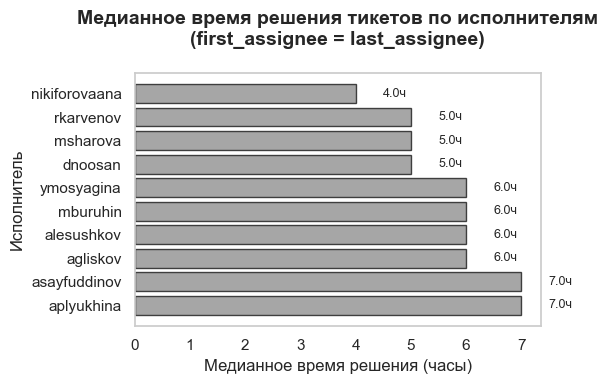

In [241]:
# график
plt.figure(figsize=(6, 4))

bars = plt.barh(median_resolution_time.index, median_resolution_time['median_time'],
                color='gray', edgecolor='black', linewidth=1, alpha=0.7)

plt.title('Медианное время решения тикетов по исполнителям\n(first_assignee = last_assignee)', 
          fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Медианное время решения (часы)', fontsize=12)
plt.ylabel('Исполнитель', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Добавляем значения на столбцы
for bar, value in zip(bars, median_resolution_time['median_time']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{value:.1f}ч', ha='left', va='center', fontsize=9)

plt.grid(False)
plt.tight_layout()
plt.show()

#### Эффективность по меткам исполнителя

In [242]:
#синтаксис list comprehension
#expression: что попадает в новый список (у нас - tag)
#for item in iterable: перебираем элементы из top_n_tags
#if condition: условие фильтрации (tag in grouped_data.columns)

#top_n_tags: список самых популярных тегов (например, ['bug', 'feature', 'ui'])
#grouped_data: DataFrame с данными, по которому мы хотим фильтровать
#grouped_data.columns: все доступные столбцы в этом DataFrame

#проходим по каждому тегу в top_n_tags и проверяем,есть ли столбец с таким именем в grouped_data
#если да - тег добавится в новый список

In [243]:
#same_assignee_tickets = df[df['first_assignee'] == df['last_assignee']]

# топ меток по отфильтрованным данным
top_n_tags = same_assignee_tickets['tag'].value_counts().head(15).index.tolist()

# Группируем отфильтрованные данные по исполнителям и меткам
grouped_data = same_assignee_tickets.groupby(['first_assignee', 'tag']).size().unstack(fill_value=0)

# Оставляем только топ метки, остальные определим в "Other"
available_top_tags = [tag for tag in top_n_tags if tag in grouped_data.columns] #list comprehension
grouped_data_top = grouped_data[available_top_tags].copy()

# Добавляем колонку Other для остальных меток
other_tags = [col for col in grouped_data.columns if col not in available_top_tags]
if other_tags:
    grouped_data_top['Other'] = grouped_data[other_tags].sum(axis=1)
else:
    grouped_data_top['Other'] = 0

# отсортируем исполнителей по общему количеству тикетов
grouped_data_top = grouped_data_top.loc[grouped_data_top.sum(axis=1).sort_values(ascending=False).index]

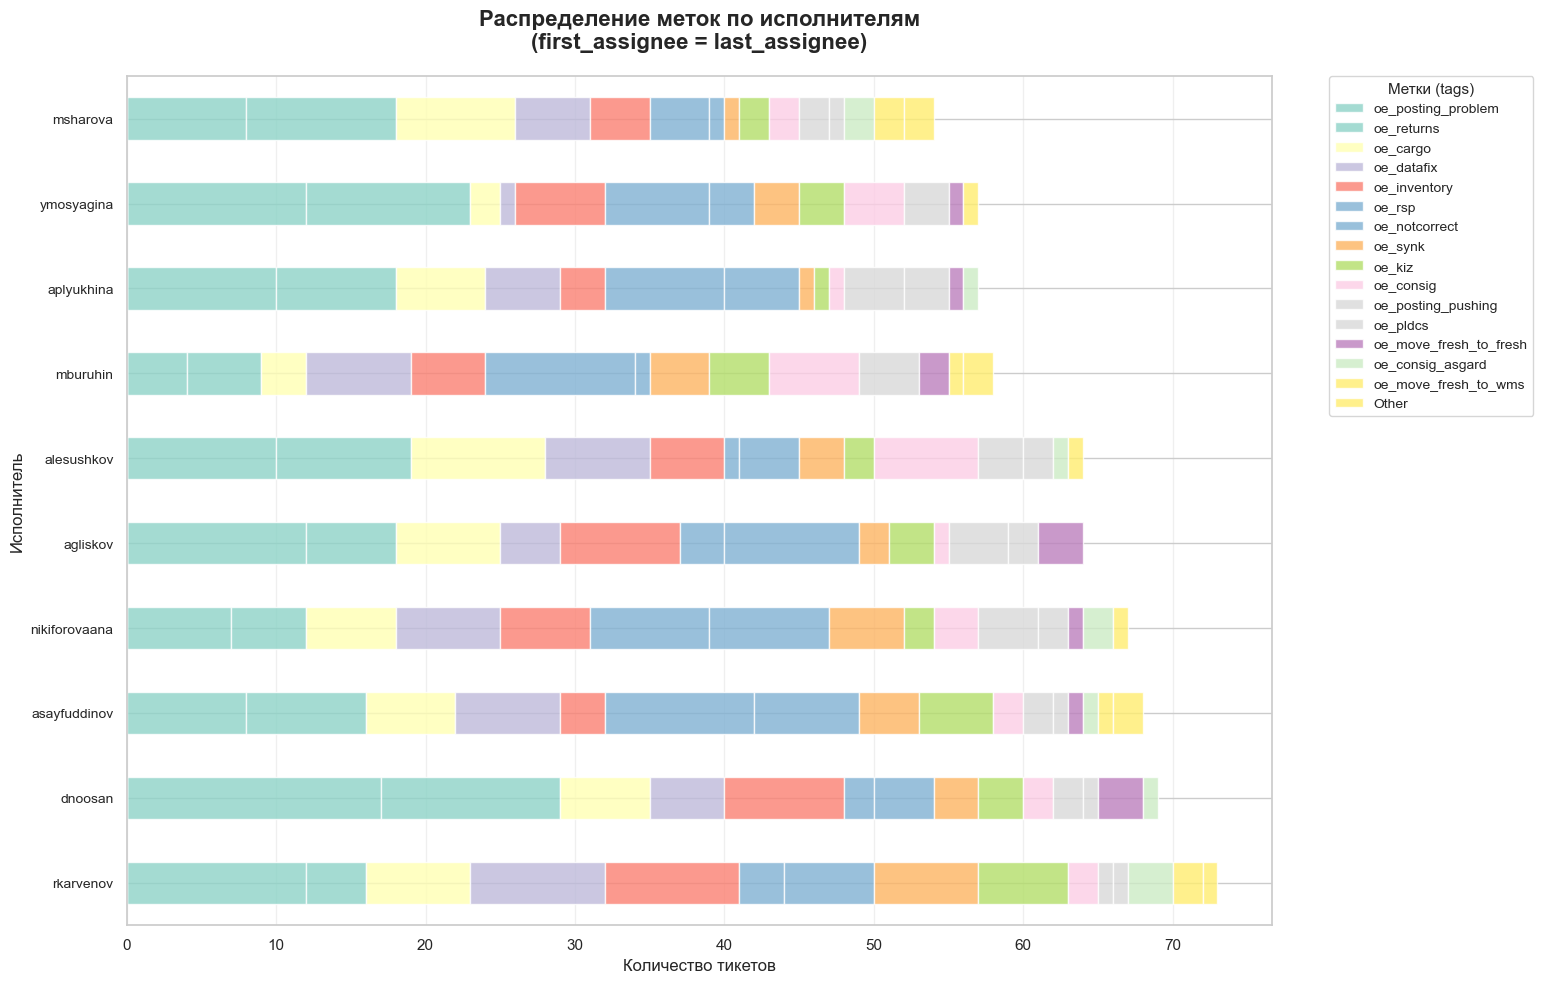

In [244]:
#график
fig, ax = plt.subplots(figsize=(16, 10))

# цветоая карта
colors = plt.cm.Set3(np.linspace(0, 1, len(grouped_data_top.columns)))
cmap = ListedColormap(colors)

#горизонтальный барплот с накоплением
bars = grouped_data_top.plot(kind='barh', stacked=True, ax=ax, colormap=cmap, alpha=0.8)

ax.set_title('Распределение меток по исполнителям\n(first_assignee = last_assignee)', 
             fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('Количество тикетов', fontsize=12)
ax.set_ylabel('Исполнитель', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='x', alpha=0.3)

# легенду вынесла справа
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., 
          title='Метки (tags)', title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(right=0.8)  # место для легенды
plt.show()